In [36]:
import sys
!{sys.executable} -m pip install alerce 
#for some reason it hated me pip installing
#and only worked if it was done in the notebook

## Import the important things and set up the data samples ##

In [37]:
# 0. Imports (there is no way I got all of them here so i hope i don't repeat any later)
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

import matplotlib.pyplot as plt

from alerce.core import Alerce

alerce = Alerce()

In [38]:
tde_sample = pd.DataFrame([
    {"oid": "ZTF26aalndlm", "name": "TDE 2026hdo", "label": 1},
    {"oid": "ZTF25aclckzl", "name": "TDE 2025aljd", "label": 1},
    {"oid": "ZTF25acgtfmh", "name": "TDE 2025ahbd", "label": 1},
    {"oid": "ZTF25abwvuln", "name": "TDE 2025abqg", "label": 1},
    {"oid": "ZTF25abcemrc", "name": "TDE 2025spf", "label": 1},
    {"oid": "ZTF25aaymnha", "name": "TDE 2025qhf", "label": 1},
    {"oid": "ZTF25aajjeon", "name": "TDE 2025hbw", "label": 1},
    {"oid": "ZTF25aafwfzz", "name": "TDE 2025cyh", "label": 1},
    {"oid": "ZTF25aagevje", "name": "TDE 2025chm", "label": 1},
    {"oid": "ZTF25aaayywb", "name": "TDE 2025ug", "label": 1},

    {"oid": "ZTF24abyhjvc", "name": "TDE 2024aepd", "label": 1},
    {"oid": "ZTF24abmzcpa", "name": "TDE 2024zau", "label": 1},
    {"oid": "ZTF24abmybnp", "name": "TDE 2024yqo", "label": 1},
    {"oid": "ZTF24abmaujk", "name": "TDE 2024ymu", "label": 1},
    {"oid": "ZTF24abjfuew", "name": "TDE 2024wsd", "label": 1},
    {"oid": "ZTF24abfuwbm", "name": "TDE 2024vip", "label": 1},
    {"oid": "ZTF22aaigqsr", "name": "TDE 2024tvd", "label": 1},
    {"oid": "ZTF24aatxshz", "name": "TDE 2024qab", "label": 1},
    {"oid": "ZTF24aaoxmyb", "name": "TDE 2024lhc", "label": 1},
    {"oid": "ZTF24aahgxiz", "name": "TDE 2024eqp", "label": 1},
    {"oid": "ZTF24aaecooj", "name": "TDE 2024bgz", "label": 1},

    {"oid": "ZTF23abohtqf", "name": "TDE 2023xen", "label": 1},
    {"oid": "ZTF23abkixdb", "name": "TDE 2023wdb", "label": 1},
    {"oid": "ZTF23aaqdjhi", "name": "TDE 2023mhs", "label": 1},
    {"oid": "ZTF23aapyidj", "name": "TDE 2023mfm", "label": 1},

    {"oid": "ZTF22abkfhua", "name": "TDE 2022wtn", "label": 1},
    {"oid": "ZTF22abegjtx", "name": "TDE 2022upj", "label": 1},
    {"oid": "ZTF22aagvrlq", "name": "TDE 2022ibq", "label": 1},
    {"oid": "ZTF20aahmtso", "name": "TDE 2022gri", "label": 1},

    {"oid": "ZTF21abxngcz", "name": "TDE 2021yzv", "label": 1},
    {"oid": "ZTF21abmwftm", "name": "TDE 2021uvz", "label": 1},
    {"oid": "ZTF21abcgnqn", "name": "TDE 2021nwa", "label": 1},
    {"oid": "ZTF21aaeoitd", "name": "TDE 2021jsg", "label": 1},

    {"oid": "ZTF20abwtifz", "name": "TDE 2020afhd", "label": 1},
    {"oid": "ZTF20acnznms", "name": "TDE 2020yue", "label": 1},
    {"oid": "ZTF20acitpfz", "name": "TDE 2020wey", "label": 1},
    {"oid": "ZTF20acaazkt", "name": "TDE 2020vdq", "label": 1},
    {"oid": "ZTF20abgwfek", "name": "TDE 2020neh", "label": 1},
    {"oid": "ZTF20aabqihu", "name": "TDE 2020pj", "label": 1},

    {"oid": "ZTF19acspeuw", "name": "TDE 2019vcb", "label": 1},
    {"oid": "ZTF19accmaxo", "name": "TDE 2019teq", "label": 1},
    {"oid": "ZTF19abidbya", "name": "TDE 2019lwu", "label": 1},
    {"oid": "ZTF19aavxfib", "name": "TDE 2019gte", "label": 1},
    {"oid": "ZTF19aapreis", "name": "TDE 2019dsg", "label": 1},
    {"oid": "ZTF19aaniqrr", "name": "TDE 2019cmw", "label": 1},
    {"oid": "ZTF19aakswrb", "name": "TDE 2019bhf", "label": 1},

    {"oid": "ZTF18acmqevd", "name": "TDE 2018mqa", "label": 1},
    {"oid": "ZTF19aabbnzo", "name": "TDE 2018lna", "label": 1},
    {"oid": "ZTF18aahqkbt", "name": "TDE 2018bsi", "label": 1},
]) #most from TNS but some straight from the paper 

In [39]:
from astropy.table import Table

mq = Table.read("milliquas.fits").to_pandas() #reading in the milliquas data
print(mq.columns)
mq.head()

Index(['RA', 'DEC', 'NAME', 'TYPE', 'RMAG', 'BMAG', 'COMMENT', 'R', 'B', 'Z',
       'CITE', 'ZCITE', 'XNAME', 'RNAME', 'LOBE1', 'LOBE2'],
      dtype='object')


,RA,DEC,NAME,TYPE,RMAG,BMAG,COMMENT,R,B,Z,CITE,ZCITE,XNAME,RNAME,LOBE1,LOBE2
0,0.000629,35.517844,b'SDSS J000000.15+353104.2 ',b'Q ',17.930000,19.000000,b'pG ',b'-',b'-',0.845,b'DR16Q ',b'DR16 ',NaN,NaN,NaN,NaN
1,0.000657,-20.074344,b'UVQSJ000000.15-200427.7 ',b'AX ',17.900000,18.459999,b'pG ',b'-',b'1',0.291,b'UVQS ',b'UVQS ',b'LSXPS J000000.1-200426',NaN,NaN,NaN
2,0.001450,31.057037,b'SDSS J000000.33+310325.3 ',b'Q ',19.950001,21.290001,b'jN ',b'-',b'-',2.035,b'DR16Q ',b'DR16 ',NaN,NaN,NaN,NaN
3,0.001527,27.732283,b'SDSS J000000.36+274356.2 ',b'Q ',21.750000,21.910000,b'g ',b'-',b'-',1.771,b'DR16Q ',b'DR16 ',NaN,NaN,NaN,NaN
4,0.001535,7.064129,b'SDSS J000000.36+070350.8 ',b'Q ',21.870001,22.110001,b'g ',b'-',b'-',1.574,b'DR16Q ',b'DR16 ',NaN,NaN,NaN,NaN


In [40]:
# fix weird FITS byte strings → normal text (girl why all the b's)
mq["TYPE"] = mq["TYPE"].apply(lambda x: x.decode("utf-8") if isinstance(x, bytes) else str(x)).str.strip()
mq["NAME"] = mq["NAME"].apply(lambda x: x.decode("utf-8") if isinstance(x, bytes) else str(x)).str.strip()

In [41]:
mq[["TYPE", "NAME"]].head()
mq["TYPE"].unique()[:10]

array(['Q', 'AX', 'A', 'N', 'QR', 'X', 'R', 'NX', 'K', 'NR'], dtype=object)

In [42]:
agn = mq[mq["TYPE"].str.contains("A", na=False)].copy() #checks for A and only keeps those because they are AGN

In [43]:
agn_try = agn.sample(500, random_state=42).copy() #this randomly selects 500 objects from the dataset to query for

In [44]:
def find_ztf_match(ra, dec, radius_arcsec=2.0):
    """cone search ALeRCE around a position → return ZTF oid or None"""
    try:
        res = alerce.query_objects(
            survey="ztf",
            ra=float(ra),
            dec=float(dec),
            radius=radius_arcsec,  # search radius (arcsec)
            format="pandas"
        )

        if res is None or len(res) == 0:
            return None

        if "dist" in res.columns:  # pick nearest match if available
            res = res.sort_values("dist")

        return res.iloc[0]["oid"]

    except Exception as e:
        print(f"match failed at RA={ra}, Dec={dec}: {e}")
        return None

In [45]:
agn_try["oid"] = agn_try.apply(
    lambda row: find_ztf_match(row["RA"], row["DEC"], radius_arcsec=2.0),
    axis=1
)
# this applies the cone search to find the oid and then matches it with the AGN within 2 arcsec

agn_matches = agn_try.dropna(subset=["oid"]).copy() #keeps only the rows where the match was found
print("Matched to ZTF:", len(agn_matches))
agn_matches[["NAME", "TYPE", "RA", "DEC", "oid"]].head()

Matched to ZTF: 136


,NAME,TYPE,RA,DEC,oid
146055,ESO 544-19,AR,32.884569,-20.038982,ZTF18ackasrz
553443,SDSS J122505.88+304937.2,AR,186.274519,30.827018,ZTF18aauvbiy
425618,SDSS J104330.05+512128.9,A,160.875269,51.358045,ZTF19aanglav
583730,SDSS J124726.72+074840.7,A,191.861354,7.811339,ZTF19aaozmip
540803,MCG 4-29-055,AR,183.903845,21.909189,ZTF22absapsy


In [46]:
agn_milliquas_sample = agn_matches[["oid", "NAME"]].copy() #the columns we actually need
agn_milliquas_sample = agn_milliquas_sample.rename(columns={"NAME": "name"}) #makes sure the samples match
agn_milliquas_sample["label"] = 0 #its an AGN

agn_milliquas_sample

,oid,name,label
146055,ZTF18ackasrz,ESO 544-19,0
553443,ZTF18aauvbiy,SDSS J122505.88+304937.2,0
425618,ZTF19aanglav,SDSS J104330.05+512128.9,0
583730,ZTF19aaozmip,SDSS J124726.72+074840.7,0
540803,ZTF22absapsy,MCG 4-29-055,0
...,...,...,...
350732,ZTF18acegcpk,HS 0940+4820,0
470927,ZTF19acmzelt,PGC 1040278,0
727711,ZTF18acawswo,PGC 140343,0
784802,ZTF20abbeozr,SDSS J152903.43+182318.9,0


In [47]:
agn_tns_sample = pd.DataFrame([ #long list of some great AGN from TNS
    {"oid": "ZTF25aavxfcj", "name": "AT 2025rpv", "label": 0},
    {"oid": "ZTF24abwywkf", "name": "AT 2024aghq", "label": 0},
    {"oid": "ZTF24aapsitb", "name": "AT 2024jxi", "label": 0},
    {"oid": "ZTF24aalnrat", "name": "AT 2024hxu", "label": 0},
    {"oid": "ZTF24aaiiosm", "name": "AT 2024gbm", "label": 0},
    {"oid": "ZTF24aafaxvf", "name": "AT 2024ehz", "label": 0},
    {"oid": "ZTF23absjgzg", "name": "AT 2023zyp", "label": 0},
    {"oid": "ZTF23abqkwzr", "name": "AT 2023zgo", "label": 0},
    {"oid": "ZTF22abveoak", "name": "AT 2023xbu", "label": 0},
    {"oid": "ZTF23abbbawg", "name": "AT 2023sas", "label": 0},
    {"oid": "ZTF23aahbtjx", "name": "AT 2023hzb", "label": 0},

    {"oid": "ZTF22aaqccka", "name": "AT 2022aeys", "label": 0},
    {"oid": "ZTF22aabwxtw", "name": "AT 2022aerd", "label": 0},

    {"oid": "ZTF21aaltbzp", "name": "AT 2021ahuk", "label": 0},
    {"oid": "ZTF21abxowzx", "name": "AT 2021yzu", "label": 0},
    {"oid": "ZTF21aatlewl", "name": "AT 2021rsz", "label": 0},
    {"oid": "ZTF21aalxxzn", "name": "AT 2021fxu", "label": 0},

    {"oid": "ZTF20acvfraq", "name": "AT 2020adpi", "label": 0},
    {"oid": "ZTF20acnviht", "name": "AT 2020adgg", "label": 0},
    {"oid": "ZTF20acwyoqx", "name": "AT 2020acob", "label": 0},
    {"oid": "ZTF20aanlygx", "name": "AT 2020abea", "label": 0},
    {"oid": "ZTF20acgcnjt", "name": "AT 2020vdo", "label": 0},
    {"oid": "ZTF20abgxlut", "name": "AT 2020oio", "label": 0},
    {"oid": "ZTF20abbhlct", "name": "AT 2020mma", "label": 0},
    {"oid": "ZTF20aasivtu", "name": "AT 2020fhp", "label": 0},

    {"oid": "ZTF18acowezf", "name": "AT 2019aawv", "label": 0},
    {"oid": "ZTF19aazdroc", "name": "AT 2019aaot", "label": 0},
    {"oid": "ZTF18abmwqkr", "name": "AT 2019pgx", "label": 0},
    {"oid": "ZTF19abiagjr", "name": "AT 2019mzt", "label": 0},
    {"oid": "ZTF19aavndxo", "name": "AT 2019fyt", "label": 0},
    {"oid": "ZTF18aaqzhib", "name": "AT 2019cvi", "label": 0},
    {"oid": "ZTF19aaodsna", "name": "AT 2019csk", "label": 0},
    {"oid": "ZTF18abrzevn", "name": "AT 2019byp", "label": 0},
    {"oid": "ZTF19aaiqmgl", "name": "AT 2019avd", "label": 0},
    {"oid": "ZTF18aailsee", "name": "AT 2019ju", "label": 0},

    {"oid": "ZTF18abuoilc", "name": "AT 2018mci", "label": 0},
    {"oid": "ZTF18adbzccu", "name": "AT 2018lkb", "label": 0},
    {"oid": "ZTF18aclgopa", "name": "AT 2018iye", "label": 0},
    {"oid": "ZTF18aarybyq", "name": "AT 2018ikn", "label": 0},
    {"oid": "ZTF18aakaajs", "name": "AT 2018iem", "label": 0},
    {"oid": "ZTF18aapzqup", "name": "AT 2018iej", "label": 0},
    {"oid": "ZTF18aaadtdc", "name": "AT 2018hve", "label": 0},
    {"oid": "ZTF18abtgnxs", "name": "AT 2018gkq", "label": 0},
    {"oid": "ZTF18abnuhuy", "name": "AT 2018fzo", "label": 0},
    {"oid": "ZTF18aajupnt", "name": "AT 2018dyk", "label": 0},
])

# Now that we have the data we can get the features and build a wonderful table

In [48]:
# feature extractor
def get_alerce_features(oid):
    try:  # avoid crashing if query fails
        feats = alerce.query_features(oid, format="pandas", survey="ztf")  # get those ALeRCE features

        if feats is None or len(feats) == 0:
            print(f"No features found for {oid}")
            return None

        # handle "long" format (name/value rows)
        if "name" in feats.columns and "value" in feats.columns:
            row = {}
            for _, r in feats.iterrows():  # add fid suffix so bands don’t overwrite
                name = str(r["name"])
                if "fid" in feats.columns and pd.notna(r["fid"]):
                    key = f"{name}_{int(r['fid'])}"
                else:
                    key = name
                row[key] = r["value"]

            row["oid"] = oid  # keep object id
            return row

        # handle "wide" format (already one row)
        row = feats.iloc[0].to_dict()
        row["oid"] = oid
        return row

    except Exception as e:
        print(f"failed for {oid}: {e}")
        return None

In [49]:
def build_feature_table(labels_df):  # convert objects into feature table with labels
    feature_rows = []

    for _, r in labels_df.iterrows():
        row = get_alerce_features(r["oid"])  # load ALeRCE features
        if row is not None:
            row["label"] = r["label"]
            row["name"] = r["name"]
            feature_rows.append(row)

    data = pd.DataFrame(feature_rows)  # final table
    return data

In [50]:
candidate_features = [
    "g-r_mean_12",
    "g-r_max_12",
    "color_variation_12",
    "mean_distnr_12",
    "sigma_distnr_12",
    "dist_nr_0",
    "distpsnr1_0",
    "TDE_decay_1",
    "TDE_decay_2",
    "TDE_decay_chi_1",
    "TDE_decay_chi_2",
    "fleet_chi_1",
    "fleet_chi_2",
    "fleet_w_1",
    "fleet_w_2",
    "SPM_tau_rise_1",
    "SPM_tau_rise_2",
    "SPM_tau_fall_1",
    "SPM_tau_fall_2",
    "LinearTrend_1",
    "LinearTrend_2",
    "Amplitude_1",
    "Amplitude_2",
    "Std_1",
    "Std_2",
    "ExcessVar_1",
    "ExcessVar_2",
]

# Making the function to run the models and running them

In [51]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, roc_auc_score,
    ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.dummy import DummyClassifier #bad on purpose

def run_models(data, dataset_name="dataset"): 
    #this is a crazy block of code so I could combine everything I needed into one super loop
    #so i could run it with the different data and not have to type it all out every time
    usable_features = [f for f in candidate_features if f in data.columns] #makes sure all the data we need is there
    print(f"\n=== {dataset_name} ===")
    print("Using:", usable_features)

    X = data[usable_features].apply(pd.to_numeric, errors="coerce") #input in number form
    y = data["label"] #answer key

    # single train/test split for diagnostic plots
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.25,
        random_state=42,
        stratify=y #keeps the same ratio of tde/agn roughly for both sets
    )

    
    
    # benchmark model that always predicts the most common class
    dummy = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", DummyClassifier(strategy="most_frequent"))
    ])
    dummy.fit(X_train, y_train) 
    dummy_pred = dummy.predict(X_test)

    print("\nBenchmark model: always predicts majority class")
    print(classification_report(y_test, dummy_pred, digits=3, zero_division=0)) # the last thing just prevents warnings

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        dummy_pred,
        display_labels=["AGN", "TDE"],
        cmap="Greys",
        values_format="d"
    )
    plt.title(f"Benchmark Confusion Matrix: {dataset_name}")
    plt.tight_layout()
    plt.show()

    
    
    # logistic regression model
    logreg = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ])
    # Logistic regression needs scaled features, so I include StandardScaler.
    # Balanced class weights help because the AGN and TDE samples are not perfectly equal.
    logreg.fit(X_train, y_train)
    pred = logreg.predict(X_test)
    prob = logreg.predict_proba(X_test)[:, 1] #probability that it is TDE

    print("\nLogistic regression test split:")
    print(classification_report(y_test, pred, digits=3))
    print("ROC-AUC:", roc_auc_score(y_test, prob)) # how well the model separates TDEs from AGN using probabilities

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        pred,
        display_labels=["AGN", "TDE"],
        cmap="Purples",
        values_format="d"
    )
    plt.title(f"Confusion Matrix: Logistic Regression ({dataset_name})")
    plt.tight_layout()
    plt.show()

    RocCurveDisplay.from_estimator(
        logreg,
        X_test,
        y_test,
        name="Logistic Regression"
    )
    #The ROC curve shows the tradeoff between true positive rate and false positive rate as the classification threshold changes
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier") #adds the diagonal random-classifier line
    plt.title(f"ROC Curve: Logistic Regression ({dataset_name})") #A good model should curve above this line
    plt.legend()
    plt.tight_layout()
    plt.show()

    # random forest model
    # Random forests do not need feature scaling because tree splits are based on thresholds.
    # I limit the tree depth because the dataset is small <3
    rf = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", RandomForestClassifier(
            n_estimators=300,
            max_depth=5,
            random_state=42,
            class_weight="balanced"
        ))
    ])

    rf.fit(X_train, y_train)
    rf_pred = rf.predict(X_test)
    rf_prob = rf.predict_proba(X_test)[:, 1]

    print("\nRandom forest test split:")
    print(classification_report(y_test, rf_pred, digits=3))
    print("ROC-AUC:", roc_auc_score(y_test, rf_prob))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        rf_pred,
        display_labels=["AGN", "TDE"],
        cmap="Purples",
        values_format="d"
    )
    plt.title(f"Confusion Matrix: Random Forest ({dataset_name})")
    plt.tight_layout()
    plt.show()

    RocCurveDisplay.from_estimator(
        rf,
        X_test,
        y_test,
        name="Random Forest"
    )
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
    plt.title(f"ROC Curve: Random Forest ({dataset_name})")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # random forest feature importance
    importances = rf.named_steps["clf"].feature_importances_

    importance_df = pd.DataFrame({
        "feature": usable_features,
        "importance": importances
    }).sort_values("importance", ascending=False)

    plt.figure(figsize=(8, 5))
    plt.barh(
        importance_df["feature"].head(12)[::-1],
        importance_df["importance"].head(12)[::-1]
    )
    #makes a table of features and their importances, sorted from most important to least important
    plt.xlabel("Feature importance")
    plt.title(f"Top Random Forest Features ({dataset_name})")
    plt.tight_layout()
    plt.show()

    # cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    #in logreg
    auc_scores = cross_val_score(logreg, X, y, cv=cv, scoring="roc_auc")
    f1_scores = cross_val_score(logreg, X, y, cv=cv, scoring="f1")
    #in random forext
    rf_auc_scores = cross_val_score(rf, X, y, cv=cv, scoring="roc_auc")
    rf_f1_scores = cross_val_score(rf, X, y, cv=cv, scoring="f1")

    print("\nLogistic regression cross-validation:")
    print("ROC-AUC scores:", auc_scores)
    print("Mean ROC-AUC:", auc_scores.mean(), "+/-", auc_scores.std())
    print("F1 scores:", f1_scores)
    print("Mean F1:", f1_scores.mean(), "+/-", f1_scores.std())

    print("\nRandom forest cross-validation:")
    print("RF ROC-AUC:", rf_auc_scores.mean(), "+/-", rf_auc_scores.std())
    print("RF F1:", rf_f1_scores.mean(), "+/-", rf_f1_scores.std())

    #return dictionary for the important values for laterrr
    return {
        "X": X,
        "y": y,
        "usable_features": usable_features,
        "logreg_model": logreg,
        "rf_model": rf,
        "logreg_auc": auc_scores,
        "logreg_f1": f1_scores,
        "rf_auc": rf_auc_scores,
        "rf_f1": rf_f1_scores,
        "rf_feature_importance": importance_df
    } #ultimate pipeline

## TNS Run

label
1    49
0    45
Name: count, dtype: int64
failed for ZTF26aalndlm: {'Error code': 404, 'Message': 'An error with the API occurred.', 'Data': {}}
No features found for ZTF25aavxfcj
No features found for ZTF19aavndxo
(91, 270)

=== TDE vs TNS AGN ===
Using: ['g-r_mean_12', 'g-r_max_12', 'color_variation_12', 'mean_distnr_12', 'sigma_distnr_12', 'dist_nr_0', 'distpsnr1_0', 'TDE_decay_1', 'TDE_decay_2', 'TDE_decay_chi_1', 'TDE_decay_chi_2', 'fleet_chi_1', 'fleet_chi_2', 'fleet_w_1', 'fleet_w_2', 'SPM_tau_rise_1', 'SPM_tau_rise_2', 'SPM_tau_fall_1', 'SPM_tau_fall_2', 'LinearTrend_1', 'LinearTrend_2', 'Amplitude_1', 'Amplitude_2', 'Std_1', 'Std_2', 'ExcessVar_1', 'ExcessVar_2']

Benchmark model: always predicts majority class
              precision    recall  f1-score   support

           0      0.000     0.000     0.000        11
           1      0.522     1.000     0.686        12

    accuracy                          0.522        23
   macro avg      0.261     0.500     0.343   

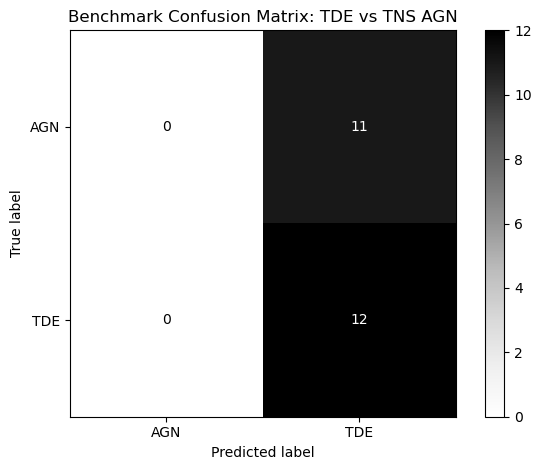


Logistic regression test split:
              precision    recall  f1-score   support

           0      0.786     1.000     0.880        11
           1      1.000     0.750     0.857        12

    accuracy                          0.870        23
   macro avg      0.893     0.875     0.869        23
weighted avg      0.898     0.870     0.868        23

ROC-AUC: 0.9242424242424242


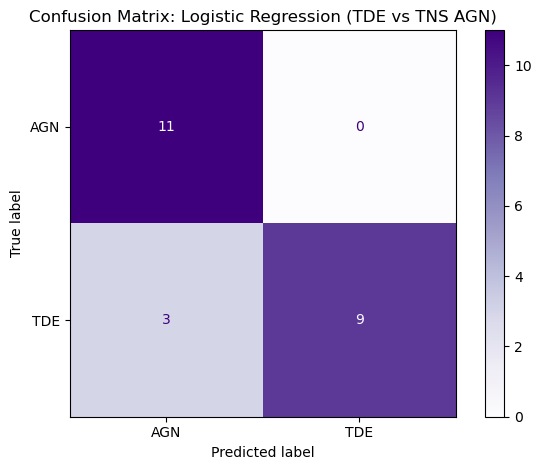

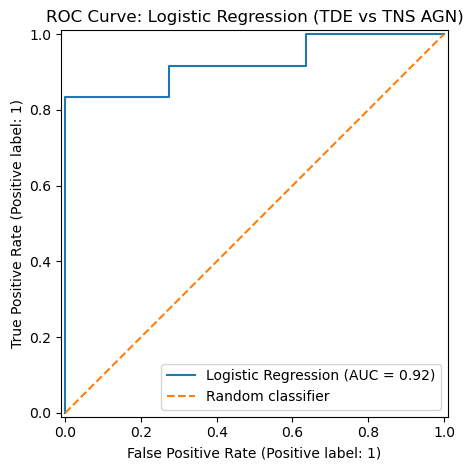


Random forest test split:
              precision    recall  f1-score   support

           0      0.846     1.000     0.917        11
           1      1.000     0.833     0.909        12

    accuracy                          0.913        23
   macro avg      0.923     0.917     0.913        23
weighted avg      0.926     0.913     0.913        23

ROC-AUC: 0.9166666666666666


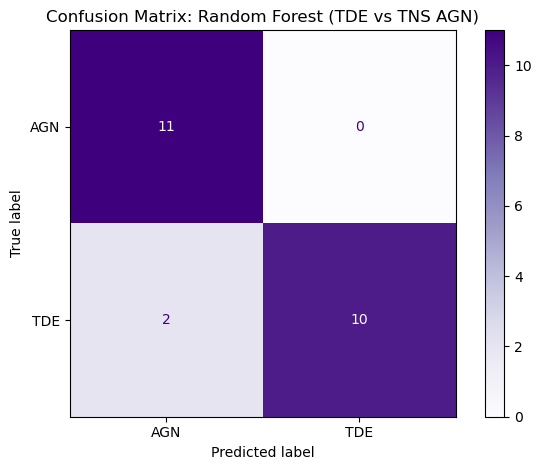

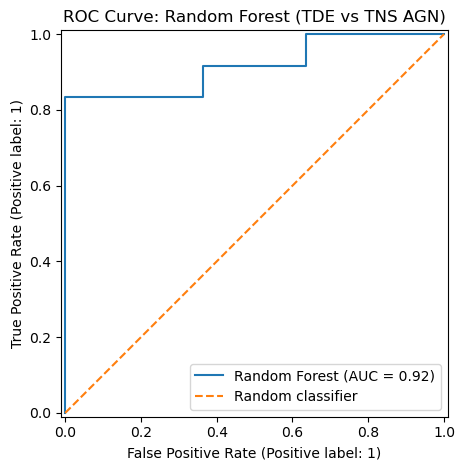

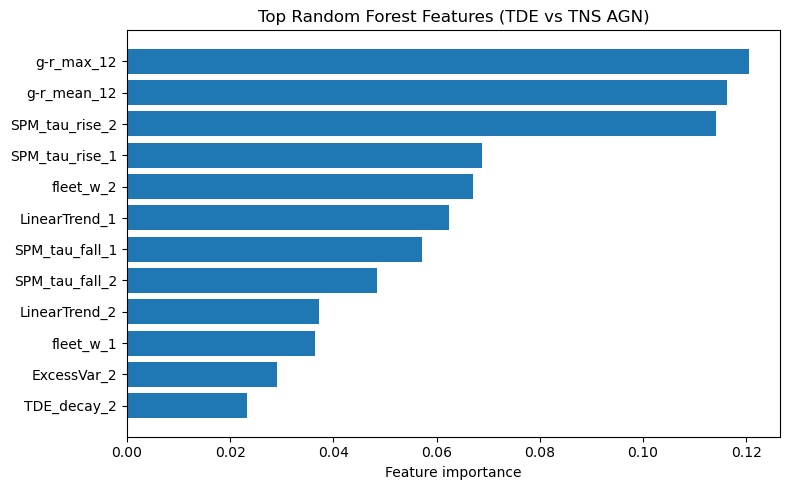


Logistic regression cross-validation:
ROC-AUC scores: [0.72222222 0.8875     0.85       0.91358025 0.95061728]
Mean ROC-AUC: 0.864783950617284 +/- 0.07849442036443949
F1 scores: [0.73684211 0.85714286 0.81818182 0.75       0.9       ]
Mean F1: 0.8124333561175666 +/- 0.06214798883424072

Random forest cross-validation:
RF ROC-AUC: 0.921820987654321 +/- 0.06037636618462145
RF F1: 0.8755054302422722 +/- 0.07338376298911402


In [52]:
#run itttt for TNS
labels_tns = pd.concat([tde_sample, agn_tns_sample], ignore_index=True)
print(labels_tns["label"].value_counts())

data_tns = build_feature_table(labels_tns)
print(data_tns.shape)

results_tns = run_models(data_tns, "TDE vs TNS AGN")

## Milliquas Run

label
0    136
1     49
Name: count, dtype: int64
failed for ZTF26aalndlm: {'Error code': 404, 'Message': 'An error with the API occurred.', 'Data': {}}
No features found for ZTF22absapsy
No features found for ZTF23abhaded
No features found for ZTF22aaiuavl
No features found for ZTF23aahqleh
No features found for ZTF20abwytbl
No features found for ZTF26aarazzw
No features found for ZTF20acmcqwc
No features found for ZTF19aaoyejq
No features found for ZTF18abmoiwk
No features found for ZTF24abvoepj
No features found for ZTF19aankaxj
No features found for ZTF23abrmkai
No features found for ZTF20abblhyk
No features found for ZTF24aalnyas
No features found for ZTF18aamsonu
No features found for ZTF18aatghlk
No features found for ZTF18abqsibq
No features found for ZTF21aasqvmt
No features found for ZTF22abygiyh
No features found for ZTF22abxihhi
No features found for ZTF24aaivrte
No features found for ZTF19aatnfpb
No features found for ZTF23absjcmf
No features found for ZTF18acyyfpk
No feat

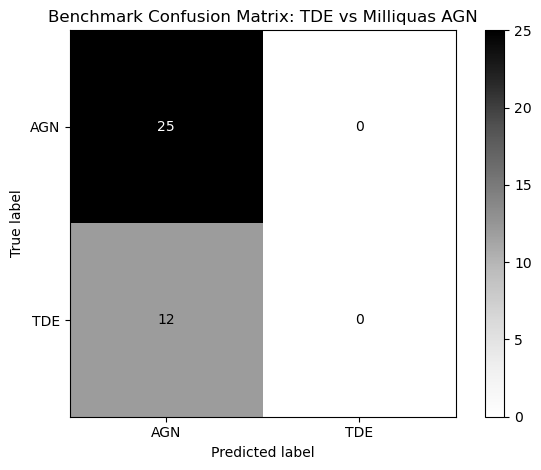


Logistic regression test split:
              precision    recall  f1-score   support

           0      0.828     0.960     0.889        25
           1      0.875     0.583     0.700        12

    accuracy                          0.838        37
   macro avg      0.851     0.772     0.794        37
weighted avg      0.843     0.838     0.828        37

ROC-AUC: 0.8500000000000001


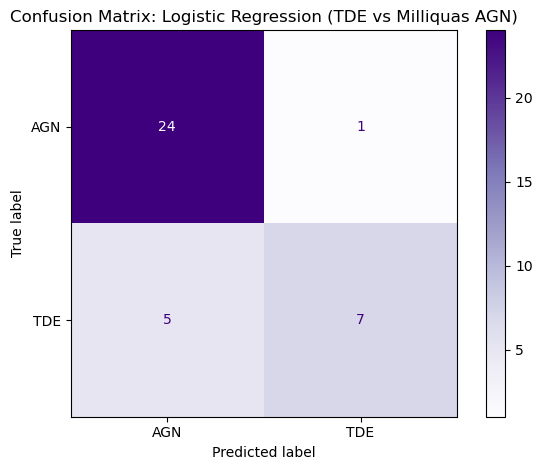

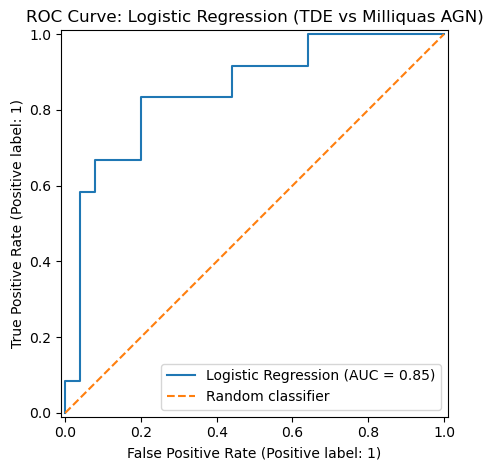


Random forest test split:
              precision    recall  f1-score   support

           0      0.862     1.000     0.926        25
           1      1.000     0.667     0.800        12

    accuracy                          0.892        37
   macro avg      0.931     0.833     0.863        37
weighted avg      0.907     0.892     0.885        37

ROC-AUC: 0.91


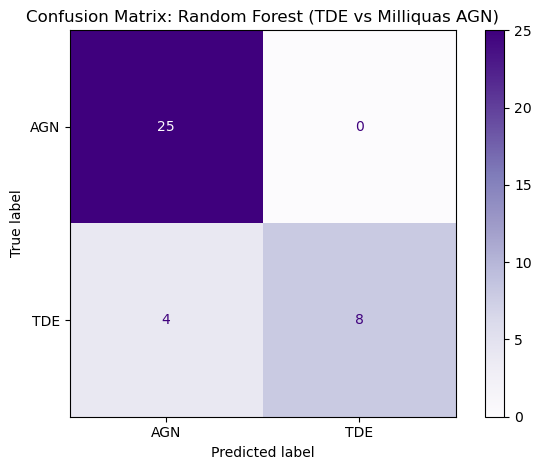

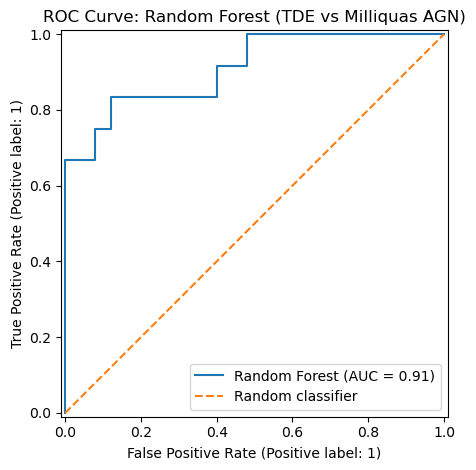

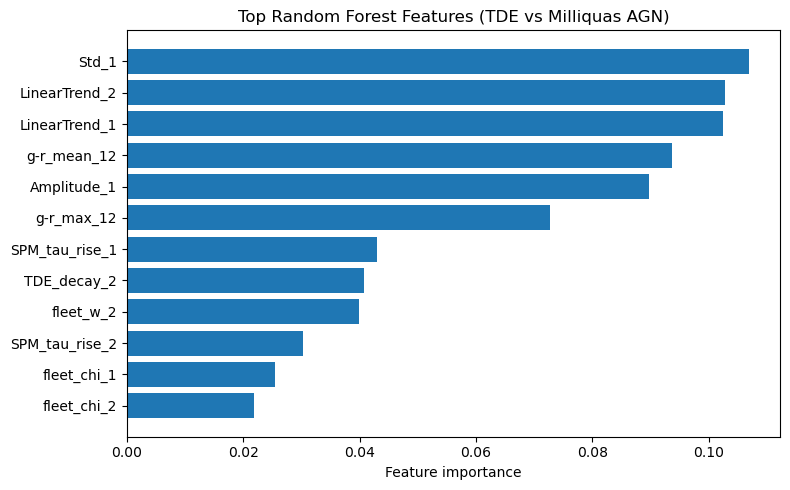


Logistic regression cross-validation:
ROC-AUC scores: [0.735      0.815      0.925      0.80555556 0.91666667]
Mean ROC-AUC: 0.8394444444444445 +/- 0.07202451571650817
F1 scores: [0.69565217 0.63636364 0.72727273 0.8        0.76190476]
Mean F1: 0.7242386598908338 +/- 0.05604806580320534

Random forest cross-validation:
RF ROC-AUC: 0.9241111111111111 +/- 0.06603740055154306
RF F1: 0.8529971988795518 +/- 0.11569819730884642


In [53]:
#run ittt for Milliquas
labels_mq = pd.concat([tde_sample, agn_milliquas_sample], ignore_index=True)
print(labels_mq["label"].value_counts())

data_mq = build_feature_table(labels_mq)
print(data_mq.shape)

results_mq = run_models(data_mq, "TDE vs Milliquas AGN")

In [54]:
results_summary = pd.DataFrame([ #i just wanted everything organized to be easier to look at and analyze
    {
        "experiment": "TDE vs TNS AGN",
        "model": "Logistic Regression",
        "roc_auc_mean": results_tns["logreg_auc"].mean(),
        "roc_auc_std": results_tns["logreg_auc"].std(),
        "f1_mean": results_tns["logreg_f1"].mean(),
        "f1_std": results_tns["logreg_f1"].std(),
    },
    {
        "experiment": "TDE vs TNS AGN",
        "model": "Random Forest",
        "roc_auc_mean": results_tns["rf_auc"].mean(),
        "roc_auc_std": results_tns["rf_auc"].std(),
        "f1_mean": results_tns["rf_f1"].mean(),
        "f1_std": results_tns["rf_f1"].std(),
    },
    {
        "experiment": "TDE vs Milliquas AGN",
        "model": "Logistic Regression",
        "roc_auc_mean": results_mq["logreg_auc"].mean(),
        "roc_auc_std": results_mq["logreg_auc"].std(),
        "f1_mean": results_mq["logreg_f1"].mean(),
        "f1_std": results_mq["logreg_f1"].std(),
    },
    {
        "experiment": "TDE vs Milliquas AGN",
        "model": "Random Forest",
        "roc_auc_mean": results_mq["rf_auc"].mean(),
        "roc_auc_std": results_mq["rf_auc"].std(),
        "f1_mean": results_mq["rf_f1"].mean(),
        "f1_std": results_mq["rf_f1"].std(),
    },
])

results_summary = results_summary.round(3)
print(results_summary)

             experiment                model  roc_auc_mean  roc_auc_std  \
0        TDE vs TNS AGN  Logistic Regression         0.865        0.078   
1        TDE vs TNS AGN        Random Forest         0.922        0.060   
2  TDE vs Milliquas AGN  Logistic Regression         0.839        0.072   
3  TDE vs Milliquas AGN        Random Forest         0.924        0.066   

   f1_mean  f1_std  
0    0.812   0.062  
1    0.876   0.073  
2    0.724   0.056  
3    0.853   0.116  


# The sea of plotting all of the interpretation graphs (also after early classifications because I was not organized and didn't want to move it back)

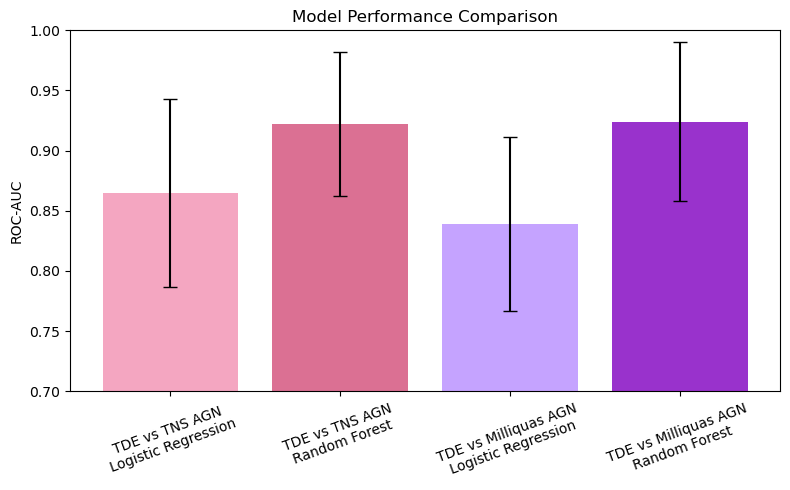

In [55]:
#model performance bar graph
plt.figure(figsize=(8,5))

labels = results_summary["experiment"] + "\n" + results_summary["model"]

colors = []
for _, row in results_summary.iterrows(): #go through the dataaaa
    exp = row["experiment"]
    model = row["model"]

    if "TNS" in exp: # this whole code section is simply because I wanted a pretty graph sorry
        # pink shades
        if model == "Logistic Regression":
            colors.append("#f4a6c1")  # light pink
        else:
            colors.append("palevioletred")  # darker pink
    else:
        # Milliquas → purple shades
        if model == "Logistic Regression":
            colors.append("#c5a3ff")  # light purple
        else:
            colors.append("darkorchid")  # dark purple

plt.bar(labels,
        results_summary["roc_auc_mean"],
        yerr=results_summary["roc_auc_std"],
        capsize=5,
        color=colors)

plt.ylabel("ROC-AUC")
plt.ylim(0.7, 1.0)
plt.title("Model Performance Comparison")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Looking at the early light curves now

In [56]:
def get_detections(oid): #queries alerce for the actual light curve data
    try:
        det = alerce.query_detections(oid=oid, format="pandas", survey="ztf") #what im lookin for
        if det is None or len(det) == 0:
            return None
        return det.sort_values("mjd").reset_index(drop=True)
    except Exception as e:
        print(f"Failed detections for {oid}: {e}")
        return None

In [57]:
det_test = get_detections("ZTF19abzrhgq")
print(det_test.head())
print(det_test.columns)

   tid           mjd              candid  fid           pid  diffmaglim  \
0  ztf  58745.499815  991499811615015001    2  991499811615   19.363945   
1  ztf  58746.503623  992503621615015001    1  992503621615   19.731804   
2  ztf  58748.481018  994481011615015013    2  994481011615   19.437870   
3  ztf  58748.521111  994521111615015002    1  994521111615   19.790651   
4  ztf  58749.470127  995470121615015004    1  995470121615   20.012611   

   isdiffpos  nid    distnr     magpsf  ...       drb  magapbig  sigmagapbig  \
0          1  991  0.072883  17.818440  ...  0.999998   17.8167       0.1131   
1          1  992  0.106353  17.631203  ...  0.999999   17.5553       0.0703   
2          1  994  0.105715  17.428600  ...  0.999998   17.7345       0.1120   
3          1  994  0.169843  17.251717  ...  0.999996   17.2574       0.0468   
4          1  995  0.149713  17.124924  ...  0.999998   17.1076       0.0336   

          rfid  has_stamp  corrected  dubious  step_id_corr  phase  

In [58]:
def early_window(det, days=30): #just decideding what the early window actually is
    if det is None or len(det) == 0: # no data
        return None
    
    t0 = det["mjd"].min() # first detection time
    early = det[det["mjd"] <= t0 + days].copy() # keep only early points
    
    if len(early) == 0: # nothing in window
        return None
    return early

In [59]:
def fit_slope(x, y):  # simple linear slope
    if len(x) < 2:
        return np.nan
    try:
        return np.polyfit(x, y, 1)[0]
    except Exception:
        return np.nan


def extract_early_features(det, oid=None, name=None, label=None, days=30):
    det_early = early_window(det, days=days)  # only keep early detections

    if det_early is None or len(det_early) < 3:  # not enough data
        return None

    # basic object/window info
    out = {
        "oid": oid,
        "name": name,
        "label": label,
        "window_days": days,
        "n_det_total": len(det_early),
        "timespan": det_early["mjd"].max() - det_early["mjd"].min(),
    }

    # extract features separately for g and r bands
    for fid, band in [(1, "g"), (2, "r")]:
        sub = det_early[det_early["fid"] == fid].sort_values("mjd")
        out[f"n_det_{band}"] = len(sub)

        if len(sub) > 0:
            mags = sub["magpsf"].values
            mjd = sub["mjd"].values

            out[f"mean_mag_{band}"] = np.mean(mags)
            out[f"amp_{band}"] = np.max(mags) - np.min(mags)
            out[f"slope_{band}"] = fit_slope(mjd, mags)

            brightest_idx = np.argmin(mags)  # lower mag = brighter
            out[f"time_to_peak_{band}"] = mjd[brightest_idx] - mjd.min()
            out[f"peak_mag_{band}"] = mags[brightest_idx]
        else:
            out[f"mean_mag_{band}"] = np.nan
            out[f"amp_{band}"] = np.nan
            out[f"slope_{band}"] = np.nan
            out[f"time_to_peak_{band}"] = np.nan
            out[f"peak_mag_{band}"] = np.nan

    # rough color from mean g and r magnitudes
    if np.isfinite(out["mean_mag_g"]) and np.isfinite(out["mean_mag_r"]):
        out["g_r_mean"] = out["mean_mag_g"] - out["mean_mag_r"]
    else:
        out["g_r_mean"] = np.nan

    # match nearest g/r points to estimate color scatter
    g = det_early[det_early["fid"] == 1][["mjd", "magpsf"]].rename(columns={"magpsf": "gmag"})
    r = det_early[det_early["fid"] == 2][["mjd", "magpsf"]].rename(columns={"magpsf": "rmag"})

    if len(g) > 0 and len(r) > 0:
        merged = pd.merge_asof(
            g.sort_values("mjd"),
            r.sort_values("mjd"),
            on="mjd",
            direction="nearest",
            tolerance=1.0
        )

        merged["g_r"] = merged["gmag"] - merged["rmag"]
        out["g_r_std"] = merged["g_r"].std() if merged["g_r"].notna().sum() >= 2 else np.nan
    else:
        out["g_r_std"] = np.nan

    # detection density in the early window
    if out["timespan"] > 0:
        out["det_per_day"] = out["n_det_total"] / out["timespan"]
    else:
        out["det_per_day"] = np.nan

    # rough brightness-change rate
    if out["timespan"] > 0:
        out["sharpness_g"] = out["amp_g"] / out["timespan"] if np.isfinite(out["amp_g"]) else np.nan
        out["sharpness_r"] = out["amp_r"] / out["timespan"] if np.isfinite(out["amp_r"]) else np.nan
    else:
        out["sharpness_g"] = np.nan
        out["sharpness_r"] = np.nan

    # check whether the light curve mostly moves one way
    for fid, band in [(1, "g"), (2, "r")]:
        sub = det_early[det_early["fid"] == fid].sort_values("mjd")

        if len(sub) >= 3:
            mag_diff = np.diff(sub["magpsf"].values)

            frac_increasing = np.mean(mag_diff > 0)
            frac_decreasing = np.mean(mag_diff < 0)
            out[f"monotonicity_{band}"] = max(frac_increasing, frac_decreasing)
        else:
            out[f"monotonicity_{band}"] = np.nan

    # color evolution over time
    if len(g) > 0 and len(r) > 0:
        color_points = pd.merge_asof(
            g.sort_values("mjd"),
            r.sort_values("mjd"),
            on="mjd",
            direction="nearest",
            tolerance=1.0
        )

        color_points["g_r"] = color_points["gmag"] - color_points["rmag"]
        color_points = color_points.dropna(subset=["g_r"])

        if len(color_points) >= 2:
            out["g_r_slope"] = fit_slope(
                color_points["mjd"].values,
                color_points["g_r"].values
            )
        else:
            out["g_r_slope"] = np.nan
    else:
        out["g_r_slope"] = np.nan

    return out

In [60]:
def build_early_feature_table(labels_df, days=30): #same thing as the other feature table but just for the actual early light curve data
    rows = []

    for _, r in labels_df.iterrows():
        det = get_detections(r["oid"])  # load detections
        feat = extract_early_features(
            det,
            oid=r["oid"],
            name=r["name"],
            label=r["label"],
            days=days
        )

        if feat is not None:  # keep valid feature rows
            rows.append(feat)

    return pd.DataFrame(rows)  # final feature table

In [61]:
#run itt to build that table
data_30_tns = build_early_feature_table(labels_tns, days=30)
print(data_30_tns.shape)
print(data_30_tns.head())
print(data_30_tns["label"].value_counts())

Failed detections for ZTF26aalndlm: {'Error code': 404, 'Message': 'An error with the API occurred.', 'Data': {}}


/var/folders/dc/5c5t9rzx2nsbhqp24y_m1rcr0000gn/T/ipykernel_77299/3154400284.py:5: RankWarning: Polyfit may be poorly conditioned
  return np.polyfit(x, y, 1)[0]


(82, 26)
            oid          name  label  window_days  n_det_total   timespan  \
0  ZTF25aclckzl  TDE 2025aljd      1           30           11  28.904051   
1  ZTF25acgtfmh  TDE 2025ahbd      1           30           11  13.038322   
2  ZTF25abwvuln  TDE 2025abqg      1           30           20  28.984988   
3  ZTF25abcemrc   TDE 2025spf      1           30            8  12.027639   
4  ZTF25aaymnha   TDE 2025qhf      1           30           75  29.938113   

   n_det_g  mean_mag_g     amp_g   slope_g  ...  time_to_peak_r  peak_mag_r  \
0        8   19.956868  1.386152 -0.046930  ...        3.886597   19.752348   
1        3   19.569293  0.155746 -0.009282  ...        8.055451   19.658900   
2       12   19.356439  1.521794 -0.054617  ...       23.874502   18.891481   
3        4   20.186707  0.381123 -0.025543  ...        7.003067   20.140558   
4       42   19.049905  1.204848 -0.027850  ...       22.957627   18.971045   

   g_r_mean   g_r_std  det_per_day  sharpness_g  shar

In [62]:
early_features = [
    "n_det_total", "timespan", "det_per_day",
    "n_det_g", "n_det_r",
    "mean_mag_g", "mean_mag_r",
    "amp_g", "amp_r",
    "sharpness_g", "sharpness_r",
    "slope_g", "slope_r",
    "monotonicity_g", "monotonicity_r",
    "time_to_peak_g", "time_to_peak_r",
    "peak_mag_g", "peak_mag_r",
    "g_r_mean", "g_r_std", "g_r_slope",
]

In [63]:
def run_early_models(data, feature_list, dataset_name="early dataset"):  # early-time version of run_models
    usable = [f for f in feature_list if f in data.columns]  # only use features that exist
    print(f"\n=== {dataset_name} ===")
    print("Using:", usable)
    
    # input features and labels
    X = data[usable].apply(pd.to_numeric, errors="coerce")
    y = data["label"]

    # logistic regression setup
    logreg = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ])

    # random forest setup
    rf = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", RandomForestClassifier(
            n_estimators=300,
            max_depth=5,
            random_state=42,
            class_weight="balanced"
        ))
    ])

    # stratified CV keeps class balance in each fold
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # evaluate both models with AUC and F1
    results = {
        "logreg_auc": cross_val_score(logreg, X, y, cv=cv, scoring="roc_auc"),
        "logreg_f1": cross_val_score(logreg, X, y, cv=cv, scoring="f1"),
        "rf_auc": cross_val_score(rf, X, y, cv=cv, scoring="roc_auc"),
        "rf_f1": cross_val_score(rf, X, y, cv=cv, scoring="f1"),
    }

    print("LogReg AUC:", results["logreg_auc"].mean(), "+/-", results["logreg_auc"].std())
    print("LogReg F1:", results["logreg_f1"].mean(), "+/-", results["logreg_f1"].std())
    print("RF AUC:", results["rf_auc"].mean(), "+/-", results["rf_auc"].std())
    print("RF F1:", results["rf_f1"].mean(), "+/-", results["rf_f1"].std())

    return results

In [64]:
#run it for just first 30 days to see what happens
results_30_tns = run_early_models(data_30_tns, early_features, "TDE vs TNS AGN, first 30 days")


=== TDE vs TNS AGN, first 30 days ===
Using: ['n_det_total', 'timespan', 'det_per_day', 'n_det_g', 'n_det_r', 'mean_mag_g', 'mean_mag_r', 'amp_g', 'amp_r', 'sharpness_g', 'sharpness_r', 'slope_g', 'slope_r', 'monotonicity_g', 'monotonicity_r', 'time_to_peak_g', 'time_to_peak_r', 'peak_mag_g', 'peak_mag_r', 'g_r_mean', 'g_r_std', 'g_r_slope']
LogReg AUC: 0.7670634920634921 +/- 0.1386369597227196
LogReg F1: 0.6502864782276546 +/- 0.10157233763275196
RF AUC: 0.7436507936507937 +/- 0.08246333465308274
RF F1: 0.6976050420168067 +/- 0.12674762365302056


In [ ]:
windows = [7, 14, 30, 60]  # early-time windows (days)
all_results = []

for days in windows:  # run pipeline for each window
    data_tmp = build_early_feature_table(labels_tns, days=days)  # extract features
    res = run_early_models(data_tmp, early_features, f"TNS, first {days} days")

    # store summary metrics
    all_results.append({
        "days": days,
        "logreg_auc_mean": res["logreg_auc"].mean(),
        "logreg_auc_std": res["logreg_auc"].std(),
        "rf_auc_mean": res["rf_auc"].mean(),
        "rf_auc_std": res["rf_auc"].std(),
        "logreg_f1_mean": res["logreg_f1"].mean(),
        "rf_f1_mean": res["rf_f1"].mean(),
        "n_objects": len(data_tmp),
    })

early_results_tns = pd.DataFrame(all_results)  # results table
print(early_results_tns)

Failed detections for ZTF26aalndlm: {'Error code': 404, 'Message': 'An error with the API occurred.', 'Data': {}}


/var/folders/dc/5c5t9rzx2nsbhqp24y_m1rcr0000gn/T/ipykernel_77299/3154400284.py:5: RankWarning: Polyfit may be poorly conditioned
  return np.polyfit(x, y, 1)[0]
/var/folders/dc/5c5t9rzx2nsbhqp24y_m1rcr0000gn/T/ipykernel_77299/3154400284.py:5: RankWarning: Polyfit may be poorly conditioned
  return np.polyfit(x, y, 1)[0]



=== TNS, first 7 days ===
Using: ['n_det_total', 'timespan', 'det_per_day', 'n_det_g', 'n_det_r', 'mean_mag_g', 'mean_mag_r', 'amp_g', 'amp_r', 'sharpness_g', 'sharpness_r', 'slope_g', 'slope_r', 'monotonicity_g', 'monotonicity_r', 'time_to_peak_g', 'time_to_peak_r', 'peak_mag_g', 'peak_mag_r', 'g_r_mean', 'g_r_std', 'g_r_slope']
LogReg AUC: 0.77 +/- 0.14352700094407322
LogReg F1: 0.7911111111111111 +/- 0.1451095797094623
RF AUC: 0.692 +/- 0.13362634470792054
RF F1: 0.6454545454545455 +/- 0.10570503166362644
Failed detections for ZTF26aalndlm: {'Error code': 404, 'Message': 'An error with the API occurred.', 'Data': {}}


/var/folders/dc/5c5t9rzx2nsbhqp24y_m1rcr0000gn/T/ipykernel_77299/3154400284.py:5: RankWarning: Polyfit may be poorly conditioned
  return np.polyfit(x, y, 1)[0]



=== TNS, first 14 days ===
Using: ['n_det_total', 'timespan', 'det_per_day', 'n_det_g', 'n_det_r', 'mean_mag_g', 'mean_mag_r', 'amp_g', 'amp_r', 'sharpness_g', 'sharpness_r', 'slope_g', 'slope_r', 'monotonicity_g', 'monotonicity_r', 'time_to_peak_g', 'time_to_peak_r', 'peak_mag_g', 'peak_mag_r', 'g_r_mean', 'g_r_std', 'g_r_slope']
LogReg AUC: 0.7863095238095238 +/- 0.04272364750340482
LogReg F1: 0.759090909090909 +/- 0.11698871114275677
RF AUC: 0.872704081632653 +/- 0.0468610714416532
RF F1: 0.7697666110978805 +/- 0.02954912853980446
Failed detections for ZTF26aalndlm: {'Error code': 404, 'Message': 'An error with the API occurred.', 'Data': {}}


/var/folders/dc/5c5t9rzx2nsbhqp24y_m1rcr0000gn/T/ipykernel_77299/3154400284.py:5: RankWarning: Polyfit may be poorly conditioned
  return np.polyfit(x, y, 1)[0]



=== TNS, first 30 days ===
Using: ['n_det_total', 'timespan', 'det_per_day', 'n_det_g', 'n_det_r', 'mean_mag_g', 'mean_mag_r', 'amp_g', 'amp_r', 'sharpness_g', 'sharpness_r', 'slope_g', 'slope_r', 'monotonicity_g', 'monotonicity_r', 'time_to_peak_g', 'time_to_peak_r', 'peak_mag_g', 'peak_mag_r', 'g_r_mean', 'g_r_std', 'g_r_slope']
LogReg AUC: 0.7670634920634921 +/- 0.1386369597227196
LogReg F1: 0.6502864782276546 +/- 0.10157233763275196
RF AUC: 0.7436507936507937 +/- 0.08246333465308274
RF F1: 0.6976050420168067 +/- 0.12674762365302056
Failed detections for ZTF26aalndlm: {'Error code': 404, 'Message': 'An error with the API occurred.', 'Data': {}}


/var/folders/dc/5c5t9rzx2nsbhqp24y_m1rcr0000gn/T/ipykernel_77299/3154400284.py:5: RankWarning: Polyfit may be poorly conditioned
  return np.polyfit(x, y, 1)[0]


In [ ]:
# plot ROC-AUC vs early-time window
plt.figure(figsize=(8,5))

plt.errorbar(
    early_results_tns["days"],
    early_results_tns["logreg_auc_mean"],
    yerr=early_results_tns["logreg_auc_std"],
    marker="o",
    label="Logistic Regression",
    color="mediumpurple"
)

plt.errorbar(
    early_results_tns["days"],
    early_results_tns["rf_auc_mean"],
    yerr=early_results_tns["rf_auc_std"],
    marker="o",
    label="Random Forest",
    color="palevioletred"
)

plt.xlabel("Days since first detection")
plt.ylabel("ROC-AUC")
plt.title("Early-time classification performance")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
def plot_class_balance(labels_df, color, title="Class balance"):
    # Count how many objects are in each class (0 = AGN, 1 = TDE)
    counts = labels_df["label"].value_counts().sort_index()

    # Map numeric labels to readable names
    label_names = {0: "AGN", 1: "TDE"}
    xlabels = [label_names.get(i, str(i)) for i in counts.index]

    plt.figure(figsize=(6, 4))

    # Plot number of objects per class
    plt.bar(xlabels, counts.values, color=color)
    plt.ylabel("Number of objects")
    plt.title(title)

    # Add the counts above each bar for readability
    for i, v in enumerate(counts.values):
        plt.text(i, v + 0.5, str(v), ha="center")

    plt.tight_layout()
    plt.show()

# examples
plot_class_balance(labels_tns,"rebeccapurple", "Class balance: TDE vs TNS AGN")
plot_class_balance(labels_mq, "palevioletred", "Class balance: TDE vs Milliquas AGN")

In [ ]:
def plot_missing_fraction(data, features, color, title="Missing fraction by feature"):
    # Keep only features that exist in the dataset
    usable = [f for f in features if f in data.columns]

    # Compute fraction of missing values for each feature
    missing_frac = data[usable].isna().mean().sort_values(ascending=False)

    plt.figure(figsize=(10, 6))

    # Horizontal bar plot of missing fractions
    plt.barh(missing_frac.index, missing_frac.values, color=color)
    plt.xlabel("Fraction missing")
    plt.title(title)

    # Limit x-axis from 0 to 1 (fraction)
    plt.xlim(0, 1)

    plt.tight_layout()
    plt.show()

# examples
plot_missing_fraction(data_tns, candidate_features,"rebeccapurple", "Missing fraction: TNS dataset")
#plot_missing_fraction(data_mq, candidate_features, "Missing fraction: Milliquas dataset")

In [ ]:
nice_titles = {
    "g_r_mean_12": "g − r Color",
    "SPM_tau_rise_1": "Rise Time",
    "Amplitude_1": "Variability Amplitude",
    "distpsnr1_0": "Host Offset"
}

def plot_feature_histograms(data, features, color1, color2, dataset_name="dataset", ncols=2):
    # Keep only features that exist
    usable = [f for f in features if f in data.columns]

    # Determine subplot layout
    n = len(usable)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 3.8*nrows))
    axes = np.array(axes).reshape(-1)

    for ax, feat in zip(axes, usable):
        # Extract feature values for each class separately
        tde = pd.to_numeric(data.loc[data["label"] == 1, feat], errors="coerce").dropna()
        agn = pd.to_numeric(data.loc[data["label"] == 0, feat], errors="coerce").dropna()

        # Plot normalized histograms (density=True)
        ax.hist(agn, bins=20, alpha=0.6, density=True, label="AGN", color=color1)
        ax.hist(tde, bins=20, alpha=0.6, density=True, label="TDE", color=color2)

        # Use nicer titles
        ax.set_title(nice_titles.get(feat, feat))
        ax.set_ylabel("Density")
        ax.legend()

    # Turn off unused subplot axes
    for ax in axes[len(usable):]:
        ax.axis("off")

    fig.suptitle(f"Feature distributions: {dataset_name}", y=1.02, fontsize=14)

    plt.tight_layout()
    plt.show()

# pick a few strong ones
explore_features = [
    "g-r_mean_12",
    #"color_variation_12",
    "SPM_tau_rise_1",
    #"SPM_tau_fall_1",
    "Amplitude_1",
    #"Std_1",
    "distpsnr1_0",
    #"mean_distnr_12",
]

plot_feature_histograms(data_tns, explore_features, "blue", "darkgreen", dataset_name="TDE vs TNS AGN")
#plot_feature_histograms(data_mq, explore_features, dataset_name="TDE vs Milliquas AGN")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
agn_oid = "ZTF19aazdroc"   # AT 2019aaot (AGN)
tde_oid = "ZTF19aapreis"   # TDE 2019dsg

# Get light curves from ALeRCE
agn_lc = get_detections(agn_oid)

# Limit AGN light curve to a similar time span for fair comparison
agn_lc = agn_lc[agn_lc["mjd"] < agn_lc["mjd"].min() + 600]
tde_lc = get_detections(tde_oid)

# Plot AGN light curve (left panel)
ax = axes[0]

for fid, color, label in [(1, "mediumseagreen", "g-band"), (2, "mediumvioletred", "r-band")]:
    sub = agn_lc[agn_lc["fid"] == fid]

    ax.errorbar(
        sub["mjd"],
        sub["magpsf"],
        yerr=sub["sigmapsf"],
        fmt="o",
        alpha=0.7,
        label=label,
        color=color
    )

ax.set_title("AGN (AT 2019aaot)")
ax.set_xlabel("MJD")
ax.set_ylabel("Apparent Magnitude (mag)")

# Invert magnitude axis (brighter = smaller number)
ax.invert_yaxis()

# Plot TDE light curve (right panel)
ax = axes[1]

for fid, color, label in [(1, "mediumseagreen", "g-band"), (2, "mediumvioletred", "r-band")]:
    sub = tde_lc[tde_lc["fid"] == fid]

    ax.errorbar(
        sub["mjd"],
        sub["magpsf"],
        yerr=sub["sigmapsf"],
        fmt="o",
        alpha=0.7,
        label=label,
        color=color
    )

ax.set_title("TDE (2019dsg)")
ax.set_xlabel("MJD")


axes[0].legend()
axes[1].legend()

plt.tight_layout()
plt.show()